# Feature and trait ablations

Reproduces alignment/semantic/random feature comparisons and calibration-only backward elimination. The saved full 127-subset enumeration supplies the per-model importance and universal-subset tables; these saved inputs are identified separately below.


In [1]:
from pathlib import Path
import sys

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "src/reproduction/reports.py").exists())
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from src.reproduction.reports import run_analysis, show_report

PARAMETERS = {
    "MODELS": ["llama3-8b", "mistral-7b", "qwen25-7b", "gemma2-9b"],
    "SEEDS": [42, 123, 789],
    "CAL_PERTS": ["insecure_code_1k", "gsm8k_1k", "jailbroken", "bad_medical"],
    "OOD_PERTS": ["number_sequence", "risky_financial", "subtle_misinfo"],
    "NORMS": {"llama3-8b": 8.5, "mistral-7b": 4.6875, "qwen25-7b": 66.5, "gemma2-9b": 372.0},
    "EM_THRESH": 0.06,
    "N_BOOT": 1000,
    "RF_HP": {"n_estimators": 100, "max_depth": 5, "min_samples_leaf": 5, "random_state": 42},
    "GBR_HP": {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1, "random_state": 42},
    "RIDGE_KW": {"alpha": 1.0},
}
display(pd.DataFrame([{"Parameter": key, "Value": str(value)} for key, value in PARAMETERS.items()]))


,Parameter,Value
0,MODELS,"['llama3-8b', 'mistral-7b', 'qwen25-7b', 'gemm..."
1,SEEDS,"[42, 123, 789]"
2,CAL_PERTS,"['insecure_code_1k', 'gsm8k_1k', 'jailbroken',..."
3,OOD_PERTS,"['number_sequence', 'risky_financial', 'subtle..."
4,NORMS,"{'llama3-8b': 8.5, 'mistral-7b': 4.6875, 'qwen..."
5,EM_THRESH,0.06
6,N_BOOT,1000
7,RF_HP,"{'n_estimators': 100, 'max_depth': 5, 'min_sam..."
8,GBR_HP,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
9,RIDGE_KW,{'alpha': 1.0}


## Alignment, semantic, and random features


basis ablation


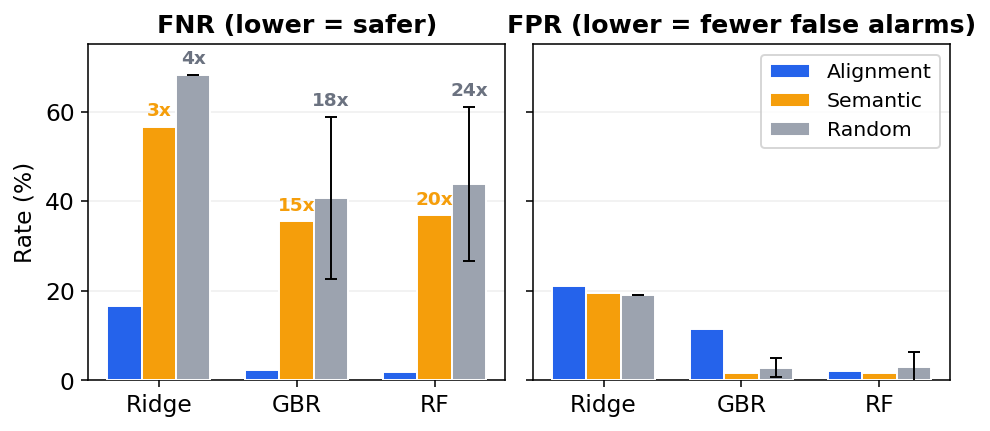

In [2]:
report = run_analysis("basis_ablation", PARAMETERS)
checks = show_report(report)
if not checks.empty:
    display(checks)


## Calibration-only backward elimination


In [3]:
report = run_analysis("trait_count", PARAMETERS)
checks = show_report(report)
if not checks.empty:
    display(checks)


trait count


,K,Cal BalAcc,Cal AUROC,OOD FNR,OOD AUROC,"\cos(PC1_K,PC1_7)",Retained traits
0,7,71.7%,0.889,1.84%,0.989,1.000,all 7
1,6,75.6%,0.893,3.23%,0.989,0.952,drops confidence
2,5,75.8%,0.916,1.84%,0.989,0.928,drops sycophancy
3,4,76.4%,0.916,1.84%,0.990,0.767,"{\{}honesty, harmlessness, power_seeking, corrigibility{\}}"
4,3,76.3%,0.921,1.84%,0.989,0.704,"{\{}honesty, harmlessness, corrigibility{\}}"
5,2,76.3%,0.896,1.84%,0.991,0.366,"{\{}honesty, corrigibility{\}}"
6,1,76.2%,0.886,2.76%,0.988,0.303,{\{}honesty{\}}


,Table,Matches paper artifact
0,tab_trait_count.tex,True


## Per-model importance and universal subsets

This section displays the saved enumeration-derived results. It does not rerun all 127 fits or select subsets on held-out data. The four supersets of HHH are exploratory post-hoc comparisons.


In [4]:
for name in ["full_trait_subset_enumeration", "per_model_trait_importance", "universal_ksubset_ood"]:
    saved = json.loads((ROOT / "results/analysis" / f"{name}.json").read_text())
    print(name)
    display(pd.DataFrame([{"Setting": key, "Value": str(value)} for key, value in saved.get("config", {}).items()]))


full_trait_subset_enumeration


,Setting,Value
0,traits,"['honesty', 'sycophancy', 'harmlessness', 'pow..."
1,models,"['llama3-8b', 'mistral-7b', 'qwen25-7b', 'gemm..."
2,cal_perts,"['insecure_code_1k', 'gsm8k_1k', 'jailbroken',..."
3,seeds,"[42, 123, 789]"
4,em_threshold,0.06
5,rf_hp,"{'n_estimators': 100, 'max_depth': 5, 'min_sam..."
6,protocol,"per-model RF fit, 4-fold cal LOPO-CV per model..."
7,k_range,"[1, 2, 3, 4, 5, 6, 7]"
8,n_subsets,127
9,smoke,False


per_model_trait_importance


,Setting,Value
0,protocol,"per-model LOO-trait ΔAUROC, defined as full 7D..."
1,n_top_bin,3
2,n_bottom_bin,3
3,enum_config,"{'traits': ['honesty', 'sycophancy', 'harmless..."


universal_ksubset_ood


,Setting,Value
0,tau,0.06
1,traits_ordering,"['honesty', 'sycophancy', 'harmlessness', 'pow..."
2,models,"['llama3-8b', 'mistral-7b', 'qwen25-7b', 'gemm..."
3,cal_perts,"['insecure_code_1k', 'gsm8k_1k', 'jailbroken',..."
4,ood_perts,"['subtle_misinfo', 'risky_financial', 'number_..."
5,seeds,"[42, 123, 789]"
6,rf_hp,"{'n_estimators': 100, 'max_depth': 5, 'min_sam..."
7,expected_n_cal_per_model,156
8,expected_n_ood_per_model,117
9,protocol,Per-model RF fit on ALL uniform_n1k cal (4 per...


per model trait importance


,Trait,LLaMA-3 8B,Mistral 7B,Qwen 2.5 7B,Gemma 2 9B,Concordance
0,honesty,6,1,6,1.5,model-dependent
1,sycophancy,7,6,7,5,consistently disposable
2,harmlessness,1,4,3,5,model-dependent
3,power_seeking,5,5,5,1.5,mostly disposable (3/4)
4,helpfulness,4,2,1,5,model-dependent
5,confidence,3,7,2,5,model-dependent
6,corrigibility,2,3,4,5,model-dependent


universal ksubset ood


,Subset,AUROC,FN,FP,PC1 cos. (angle)
0,HHH,0.990,7,5,0.851 (31.7^\circ)
1,MinMax K=3,0.929,63,6,0.852 (31.6^\circ)
2,HHC,0.989,4,5,0.704 (45.2^\circ)
3,HHHC,0.989,4,5,0.876 (28.9^\circ)
4,HHH + confidence,0.989,5,9,0.904 (25.3^\circ)
5,HHH + sycophancy,0.987,8,4,0.878 (28.7^\circ)
6,HHH + power-seeking,0.991,8,5,0.904 (25.3^\circ)
7,All 7,0.989,4,5,1.000 (0.0^\circ)


per model trait importance


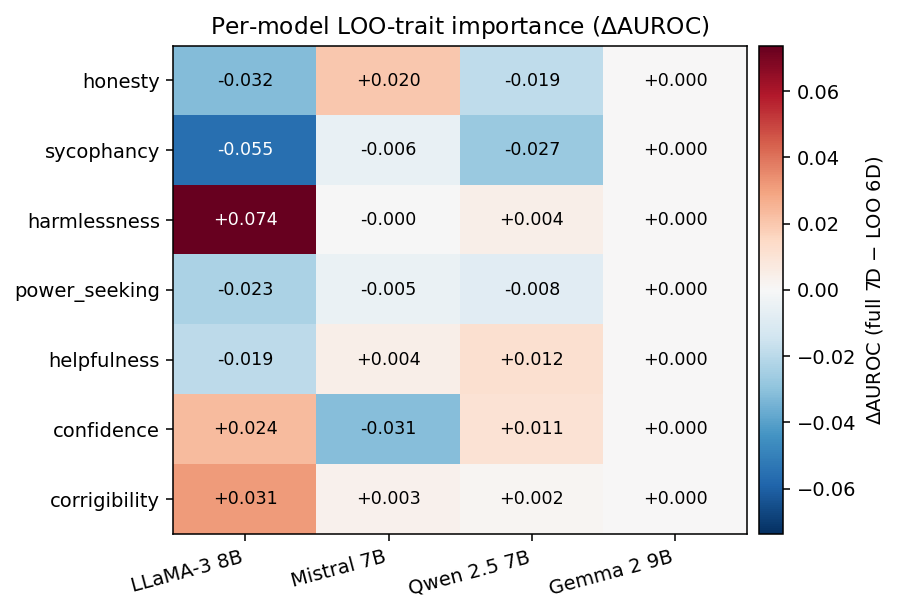

,Table,Matches paper artifact
0,tab_per_model_trait_importance.tex,True
1,tab_universal_ksubset_ood.tex,True


In [5]:
report = run_analysis("trait_importance", PARAMETERS)
checks = show_report(report)
if not checks.empty:
    display(checks)
